In [4]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

column_names = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']

df = pd.read_csv('iris_data.csv', header=None, names=column_names)

x0 = df[['SepalLength', 'PetalWidth']].values

y0 = df['Species'].apply(lambda s: 1 if s == 'Iris-setosa' else 0).values

y1= df['Species'].apply(lambda s: 1 if s == 'Iris-versicolor' else 0).values

y2= df['Species'].apply(lambda s: 1 if s == 'Iris-virginica' else 0).values

df=pd.DataFrame.from_dict({'Length (x1)':x0[:,0], 'Width (x2)':x0[:,1], 'Setosa {0,1} (y)':y})
display(df)


df=pd.DataFrame.from_dict({'Length (x1)':x0[:,0], 'Width (x2)':x0[:,1], 'Setosa {0,1} (y)':y1})
display(df)


df=pd.DataFrame.from_dict({'Length (x1)':x0[:,0], 'Width (x2)':x0[:,1], 'Setosa {0,1} (y)':y2})
display(df)


print(f'x shape : {x0.shape}')
print(f'y shape : {y.shape}')


,Length (x1),Width (x2),"Setosa {0,1} (y)"
0,5.1,0.2,1
1,4.9,0.2,1
2,4.7,0.2,1
3,4.6,0.2,1
4,5.0,0.2,1
...,...,...,...
145,6.7,2.3,0
146,6.3,1.9,0
147,6.5,2.0,0
148,6.2,2.3,0


,Length (x1),Width (x2),"Setosa {0,1} (y)"
0,5.1,0.2,0
1,4.9,0.2,0
2,4.7,0.2,0
3,4.6,0.2,0
4,5.0,0.2,0
...,...,...,...
145,6.7,2.3,0
146,6.3,1.9,0
147,6.5,2.0,0
148,6.2,2.3,0


,Length (x1),Width (x2),"Setosa {0,1} (y)"
0,5.1,0.2,0
1,4.9,0.2,0
2,4.7,0.2,0
3,4.6,0.2,0
4,5.0,0.2,0
...,...,...,...
145,6.7,2.3,1
146,6.3,1.9,1
147,6.5,2.0,1
148,6.2,2.3,1


x shape : (150, 2)
y shape : (150,)


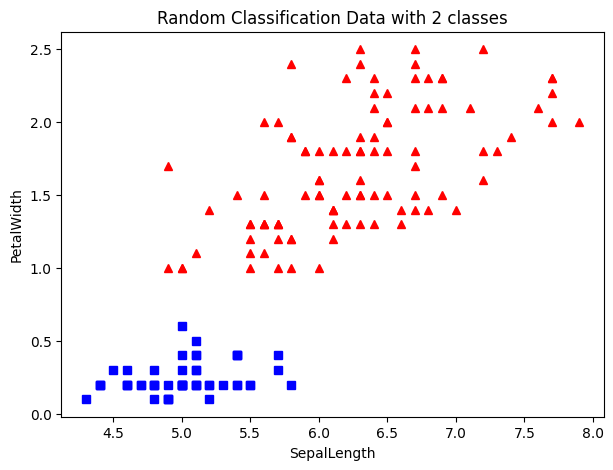

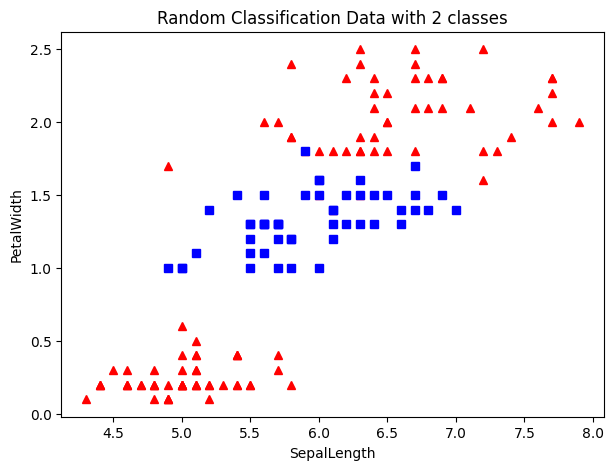

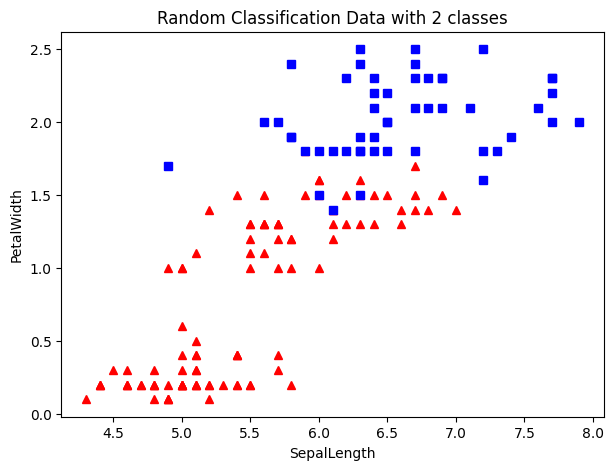

In [5]:

fig = plt.figure(figsize=(7,5))
plt.plot(x0[:, 0][y == 0], x0[:, 1][y == 0], 'r^')
plt.plot(x0[:, 0][y == 1], x0[:, 1][y == 1], 'bs')
plt.xlabel("SepalLength")
plt.ylabel("PetalWidth")
plt.title('Random Classification Data with 2 classes')
plt.show()


fig = plt.figure(figsize=(7,5))
plt.plot(x0[:, 0][y1 == 0], x0[:, 1][y1 == 0], 'r^')
plt.plot(x0[:, 0][y1 == 1], x0[:, 1][y1 == 1], 'bs')
plt.xlabel("SepalLength")
plt.ylabel("PetalWidth")
plt.title('Random Classification Data with 2 classes')
plt.show()



fig = plt.figure(figsize=(7,5))
plt.plot(x0[:, 0][y2 == 0], x0[:, 1][y2 == 0], 'r^')
plt.plot(x0[:, 0][y2 == 1], x0[:, 1][y2 == 1], 'bs')
plt.xlabel("SepalLength")
plt.ylabel("PetalWidth")
plt.title('Random Classification Data with 2 classes')
plt.show()


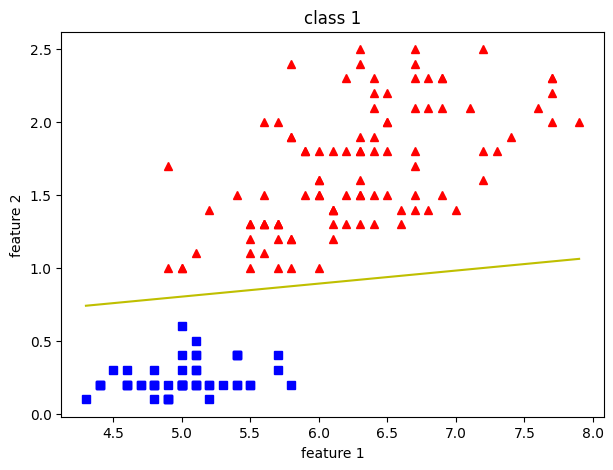

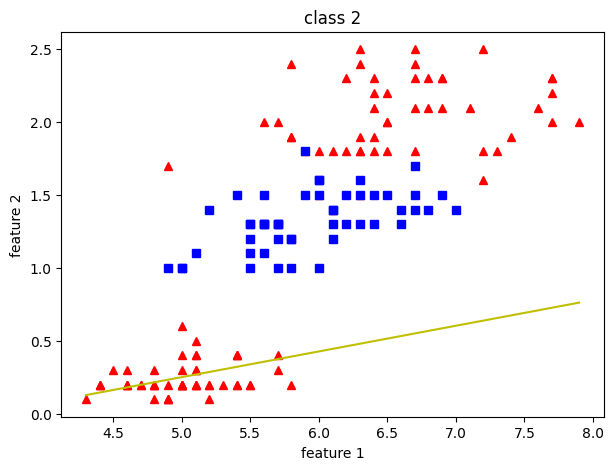

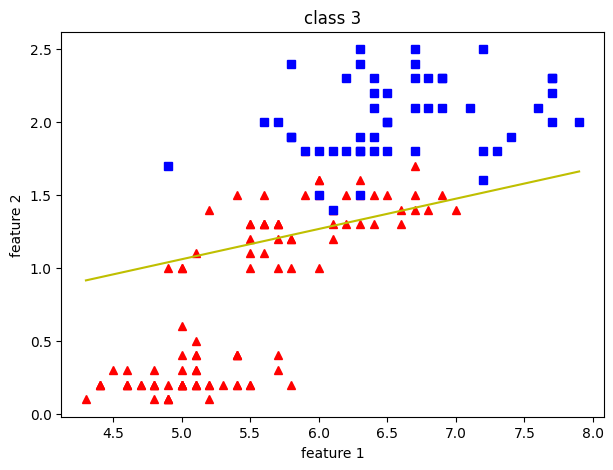

In [7]:

def step_func(z):
        return 1.0 if (z > 0) else 0.0

def perceptron(X, y, lr, epochs):
    
    # X --> Inputs.
    # y --> labels/target.
    # lr --> learning rate.
    # epochs --> Number of iterations.
    
    # m-> number of training examples, m=150
    # n-> number of features, n=2 
    m, n = X.shape
    
    # Initializing parapeters(theta) to zeros.
    # +1 in n+1 for the bias term.
    theta = np.zeros((n+1,1))
    # Empty list to store how many examples were 
    # misclassified at every iteration.
    n_miss_list = []
    
    # Training.
    for epoch in range(epochs):
        
        # variable to store #misclassified.
        n_miss = 0
        
        # looping for every example.
        for idx, x_i in enumerate(X):
            
            # Insering 1 for bias, X0 = 1. en position 0
            x_i = np.insert(x_i, 0, 1).reshape(-1,1)
            
            # Calculating prediction/hypothesis.
            y_hat = step_func(np.dot(x_i.T, theta))
            # Updating if the example is misclassified.
            if (y_hat - y[idx]) != 0:
                theta += lr*((y[idx] - y_hat)*x_i)
                
                # Incrementing by 1.
                n_miss += 1
        
        # Appending number of misclassified examples
        # at every iteration.
        n_miss_list.append(n_miss)
        
    return theta, n_miss_list


def plot_decision_boundary(X, theta,y,plot_title):
    
    # X --> Inputs
    # theta --> parameters
    
    # The Line is y=mx+c
    # So, Equate mx+c = theta0.X0 + theta1.X1 + theta2.X2
    # Solving we find m and c
    x1 = [min(X[:,0]), max(X[:,0])]
    m = -theta[1]/theta[2]
    c = -theta[0]/theta[2]
    x2 = m*x1 + c
    
    # Plotting
    fig = plt.figure(figsize=(7,5))
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "r^")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title(plot_title)
    plt.plot(x1, x2, 'y-')
    plt.show()

#=========================================
theta, miss_l = perceptron(x0, y, 0.5, 100)
#=========================================
theta1, miss_l1 = perceptron(x0, y1, 0.5, 100)

theta2, miss_l2 = perceptron(x0, y2, 0.5, 100)

#===============================
plot_decision_boundary(x0, theta,y,"class 1")

plot_decision_boundary(x0, theta1,y1,"class 2")

plot_decision_boundary(x0, theta2,y2,"class 3")
#================================